# IT3091 - Member 4 - IT23361690 - Gunathilake B.M.P



In [1]:
from pathlib import Path

REPO_PATH = Path("/content/IT3091---Machine-Learning-Assignment")

if not REPO_PATH.exists():
    !git clone https://github.com/DTD-Wijesinghe/IT3091---Machine-Learning-Assignment.git

%cd /content/IT3091---Machine-Learning-Assignment

Cloning into 'IT3091---Machine-Learning-Assignment'...
remote: Enumerating objects: 182, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 182 (delta 23), reused 27 (delta 8), pack-reused 132 (from 1)
Receiving objects: 100% (182/182), 8.49 MiB | 15.64 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/IT3091---Machine-Learning-Assignment


## Member 4 - Model training, evaluation and final output

In [2]:
!pip -q install openpyxl joblib

import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.multioutput import MultiOutputRegressor
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

REPO_PATH = Path("/content/IT3091---Machine-Learning-Assignment")
PREPROCESSED_PATH = REPO_PATH / "Preprocessed Datasets"

PREPROCESSED_PATH.mkdir(
    parents=True,
    exist_ok=True
)

FINAL_DATA_FILE = (
    PREPROCESSED_PATH
    / "03_final_modelling_dataset.csv"
)

if not FINAL_DATA_FILE.exists():
    raise FileNotFoundError(
        "Member 3 final modelling dataset is missing. "
        "Make sure Member 3 pushed the corrected file first."
    )

model_data = pd.read_csv(
    FINAL_DATA_FILE,
    parse_dates=[
        "ForecastDate",
        "WeatherWindowStart",
        "WeatherWindowEnd",
        "AnchorDate"
    ]
)

required_leakage_cols = {
    "ForecastDate",
    "WeatherWindowStart",
    "WeatherWindowEnd",
    "Rainfall_3M_mm",
    "TempMean_3M_C",
    "WindSpeed_3M_kmh",
    "SolarRadiation_3M_MJ_m2",
    "ET0_3M_mm"
}

missing_cols = (
    required_leakage_cols
    - set(model_data.columns)
)

if missing_cols:
    raise KeyError(
        "Final data is not the corrected leakage-safe version. "
        f"Missing columns: {sorted(missing_cols)}"
    )

if not (
    model_data["WeatherWindowEnd"]
    < model_data["ForecastDate"]
).all():
    raise ValueError(
        "Future weather leakage found in final modelling data."
    )

if not model_data["Year"].between(
    2012,
    2023
).all():
    raise ValueError(
        "Final modelling data must use the common 2012-2023 period."
    )

print("Loaded:", FINAL_DATA_FILE.name)
print("Shape:", model_data.shape)
print(
    "Year range:",
    model_data["Year"].min(),
    "-",
    model_data["Year"].max()
)

display(model_data.head())

Loaded: 03_final_modelling_dataset.csv
Shape: (359, 24)
Year range: 2012 - 2023


,District,Season,CropCategory,Crop,Year,Extent,Production,Yield_t_ha,Yield_IQR_Flag,AnchorMonth,AnchorDate,ForecastDate,WeatherWindowStart,WeatherWindowEnd,Rainfall_3M_mm,TempMean_3M_C,WindSpeed_3M_kmh,SolarRadiation_3M_MJ_m2,ET0_3M_mm,WeatherDays_3M,Leakage_Check,Weather_Completeness_OK,PrevMonthWholesalePrice_RsKg,NextMonthWholesalePrice_RsKg
0,National Total,Yala,Low Country Vegetable,Luffa,2012,1861.0,17053.0,9.163353,False,4,2012-04-01,2012-04-01,2012-01-01,2012-03-31,192.814815,24.956410,12.757428,20.491290,391.818889,91,True,True,34.223333,53.8075
1,National Total,Maha,Low Country Vegetable,Luffa,2012,2840.0,25733.0,9.060915,False,9,2012-09-01,2012-09-01,2012-06-01,2012-08-31,271.451852,26.739090,21.219847,19.938225,436.747407,92,True,True,35.477500,59.0260
2,National Total,Yala,Low Country Vegetable,Luffa,2013,1985.0,17801.0,8.967758,False,4,2013-04-01,2013-04-01,2013-01-01,2013-03-31,479.525926,24.796008,13.010247,18.615029,349.479630,90,True,True,48.970000,49.2650
3,National Total,Maha,Low Country Vegetable,Luffa,2013,3005.0,28598.0,9.516805,False,9,2013-09-01,2013-09-01,2013-06-01,2013-08-31,378.277778,26.059219,20.989211,19.044879,398.421111,92,True,True,49.625000,41.2200
4,National Total,Yala,Low Country Vegetable,Luffa,2014,1881.0,16066.0,8.541201,False,4,2014-04-01,2014-04-01,2014-01-01,2014-03-31,184.151852,25.072757,14.825597,20.222942,394.517778,90,True,True,51.710000,87.4350


In [3]:
member4_data = (
    PREPROCESSED_PATH
    / "04_final_modelling_dataset.csv"
)

model_data.to_csv(
    member4_data,
    index=False
)

TARGETS = [
    "Yield_t_ha",
    "NextMonthWholesalePrice_RsKg"
]

FEATURES = [
    "Crop",
    "Season",
    "Year",
    "Rainfall_3M_mm",
    "TempMean_3M_C",
    "WindSpeed_3M_kmh",
    "SolarRadiation_3M_MJ_m2",
    "ET0_3M_mm",
    "PrevMonthWholesalePrice_RsKg"
]

missing_model_cols = [
    c for c in FEATURES + TARGETS
    if c not in model_data.columns
]

if missing_model_cols:
    raise KeyError(
        f"Missing model columns: {missing_model_cols}"
    )

X = model_data[FEATURES].copy()
y = model_data[TARGETS].copy()

print("X:", X.shape)
print("y:", y.shape)

X: (359, 9)
y: (359, 2)


In [4]:
train_mask = (
    model_data["Year"]
    .between(2012, 2019)
)

val_mask = (
    model_data["Year"]
    .between(2020, 2021)
)

test_mask = (
    model_data["Year"]
    .between(2022, 2023)
)

X_train = X.loc[train_mask]
y_train = y.loc[train_mask]

X_val = X.loc[val_mask]
y_val = y.loc[val_mask]

X_test = X.loc[test_mask]
y_test = y.loc[test_mask]

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

if min(
    len(X_train),
    len(X_val),
    len(X_test)
) == 0:
    raise ValueError(
        "One data split is empty."
    )

Train: (237, 9)
Validation: (52, 9)
Test: (70, 9)


In [5]:
CAT_FEATURES = [
    "Crop",
    "Season"
]

NUM_FEATURES = [
    c for c in FEATURES
    if c not in CAT_FEATURES
]

try:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    onehot = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

cat_pipe = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        onehot
    )
])

num_scaled = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    )
])

num_tree = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    )
])

preprocess_scaled = (
    ColumnTransformer([
        (
            "cat",
            cat_pipe,
            CAT_FEATURES
        ),
        (
            "num",
            num_scaled,
            NUM_FEATURES
        )
    ])
)

preprocess_tree = (
    ColumnTransformer([
        (
            "cat",
            cat_pipe,
            CAT_FEATURES
        ),
        (
            "num",
            num_tree,
            NUM_FEATURES
        )
    ])
)

In [6]:
models = {
    "Dummy Baseline": Pipeline([
        (
            "prep",
            preprocess_tree
        ),
        (
            "model",
            MultiOutputRegressor(
                DummyRegressor(
                    strategy="mean"
                )
            )
        )
    ]),

    "Linear Regression": Pipeline([
        (
            "prep",
            preprocess_scaled
        ),
        (
            "model",
            MultiOutputRegressor(
                LinearRegression()
            )
        )
    ]),

    "Random Forest": Pipeline([
        (
            "prep",
            preprocess_tree
        ),
        (
            "model",
            MultiOutputRegressor(
                RandomForestRegressor(
                    n_estimators=300,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    n_jobs=-1
                )
            )
        )
    ]),

    "Gradient Boosting": Pipeline([
        (
            "prep",
            preprocess_tree
        ),
        (
            "model",
            MultiOutputRegressor(
                GradientBoostingRegressor(
                    n_estimators=200,
                    learning_rate=0.05,
                    max_depth=3,
                    random_state=RANDOM_STATE
                )
            )
        )
    ])
}

print(list(models))

['Dummy Baseline', 'Linear Regression', 'Random Forest', 'Gradient Boosting']


In [7]:
def regression_metrics(
    y_true,
    pred
):
    rows = {}

    for i, target in enumerate(
        TARGETS
    ):
        rows[target] = {
            "MAE":
                mean_absolute_error(
                    y_true.iloc[:, i],
                    pred[:, i]
                ),

            "RMSE":
                np.sqrt(
                    mean_squared_error(
                        y_true.iloc[:, i],
                        pred[:, i]
                    )
                ),

            "R2":
                r2_score(
                    y_true.iloc[:, i],
                    pred[:, i]
                )
        }

    return rows


validation_rows = []

for name, model in models.items():
    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_val
    )

    metrics = regression_metrics(
        y_val,
        pred
    )

    validation_rows.append({
        "Model":
            name,

        "Yield_MAE":
            metrics[
                "Yield_t_ha"
            ]["MAE"],

        "Yield_RMSE":
            metrics[
                "Yield_t_ha"
            ]["RMSE"],

        "Yield_R2":
            metrics[
                "Yield_t_ha"
            ]["R2"],

        "Price_MAE":
            metrics[
                "NextMonthWholesalePrice_RsKg"
            ]["MAE"],

        "Price_RMSE":
            metrics[
                "NextMonthWholesalePrice_RsKg"
            ]["RMSE"],

        "Price_R2":
            metrics[
                "NextMonthWholesalePrice_RsKg"
            ]["R2"]
    })

comparison = pd.DataFrame(
    validation_rows
)

for c in [
    "Yield_MAE",
    "Yield_RMSE",
    "Price_MAE",
    "Price_RMSE"
]:
    comparison[
        c + "_Rank"
    ] = (
        comparison[c]
        .rank(
            method="min",
            ascending=True
        )
    )

for c in [
    "Yield_R2",
    "Price_R2"
]:
    comparison[
        c + "_Rank"
    ] = (
        comparison[c]
        .rank(
            method="min",
            ascending=False
        )
    )

rank_cols = [
    c for c in comparison.columns
    if c.endswith("_Rank")
]

comparison["Balanced_Rank"] = (
    comparison[
        rank_cols
    ]
    .mean(axis=1)
)

comparison = (
    comparison
    .sort_values(
        "Balanced_Rank"
    )
    .reset_index(drop=True)
)

display(
    comparison.round(4)
)

comparison.to_csv(
    REPO_PATH
    / "validation_model_comparison.csv",
    index=False
)

,Model,Yield_MAE,Yield_RMSE,Yield_R2,Price_MAE,Price_RMSE,Price_R2,Yield_MAE_Rank,Yield_RMSE_Rank,Price_MAE_Rank,Price_RMSE_Rank,Yield_R2_Rank,Price_R2_Rank,Balanced_Rank
0,Random Forest,1.7374,2.8630,0.6842,39.0369,45.5977,0.1136,1.0,2.0,2.0,1.0,2.0,1.0,1.5000
1,Gradient Boosting,1.8127,2.8407,0.6891,40.9074,49.5481,-0.0466,2.0,1.0,3.0,2.0,1.0,2.0,1.8333
2,Dummy Baseline,3.8786,5.1136,-0.0075,36.9760,50.3629,-0.0813,4.0,4.0,1.0,3.0,4.0,3.0,3.1667
3,Linear Regression,2.2019,2.8688,0.6829,54.0488,59.3842,-0.5034,3.0,3.0,4.0,4.0,3.0,4.0,3.5000


In [8]:
BEST_MODEL_NAME = (
    comparison
    .loc[0, "Model"]
)

print(
    "Selected model:",
    BEST_MODEL_NAME
)

X_trainval = pd.concat(
    [X_train, X_val]
).sort_index()

y_trainval = pd.concat(
    [y_train, y_val]
).sort_index()

final_model = models[
    BEST_MODEL_NAME
]

final_model.fit(
    X_trainval,
    y_trainval
)

test_pred = final_model.predict(
    X_test
)

test_metrics = regression_metrics(
    y_test,
    test_pred
)

print("FINAL TEST METRICS")
print(
    json.dumps(
        test_metrics,
        indent=2
    )
)

metrics_rows = []

for target, values in test_metrics.items():
    metrics_rows.append({
        "Target": target,
        "MAE": values["MAE"],
        "RMSE": values["RMSE"],
        "R2": values["R2"]
    })

test_metrics_df = pd.DataFrame(
    metrics_rows
)

test_metrics_df.to_csv(
    REPO_PATH
    / "final_test_metrics.csv",
    index=False
)

display(
    test_metrics_df.round(4)
)

yield_test_r2 = test_metrics["Yield_t_ha"]["R2"]
price_test_r2 = test_metrics["NextMonthWholesalePrice_RsKg"]["R2"]

print("\nPERFORMANCE CHECK")
print("Yield test R2:", round(yield_test_r2, 4))
print("Price test R2:", round(price_test_r2, 4))

if price_test_r2 < 0:
    print(
        "Important limitation: the next-month price model has negative test R2. "
        "Price recommendations must be treated as weak decision-support evidence, "
        "not as reliable market forecasts."
    )

Selected model: Random Forest
FINAL TEST METRICS
{
  "Yield_t_ha": {
    "MAE": 1.3449710412967444,
    "RMSE": 1.9119066418745092,
    "R2": 0.8232308778540295
  },
  "NextMonthWholesalePrice_RsKg": {
    "MAE": 91.99496916284404,
    "RMSE": 121.17985850389756,
    "R2": -0.24491064182819144
  }
}


,Target,MAE,RMSE,R2
0,Yield_t_ha,1.345,1.9119,0.8232
1,NextMonthWholesalePrice_RsKg,91.995,121.1799,-0.2449



PERFORMANCE CHECK
Yield test R2: 0.8232
Price test R2: -0.2449
Important limitation: the next-month price model has negative test R2. Price recommendations must be treated as weak decision-support evidence, not as reliable market forecasts.


In [9]:
final_results = pd.DataFrame({
    "Actual_Yield_t_ha":
        y_test[
            "Yield_t_ha"
        ].values,

    "Predicted_Yield_t_ha":
        test_pred[:, 0],

    "Actual_NextMonthPrice_RsKg":
        y_test[
            "NextMonthWholesalePrice_RsKg"
        ].values,

    "Predicted_NextMonthPrice_RsKg":
        test_pred[:, 1]
})

display(
    final_results.head(20)
)

final_results.to_csv(
    REPO_PATH
    / "final_test_predictions.csv",
    index=False
)

,Actual_Yield_t_ha,Predicted_Yield_t_ha,Actual_NextMonthPrice_RsKg,Predicted_NextMonthPrice_RsKg
0,10.847590,11.159854,232.869841,107.130752
1,10.870996,10.665834,190.800000,166.532022
2,10.963093,10.978233,247.600000,140.201277
3,10.318842,10.833988,205.000000,102.879257
4,9.910431,9.716447,178.000000,72.537474
5,8.936834,9.895000,105.200000,123.614245
6,9.324213,9.890606,142.200000,150.644806
7,8.712354,9.856983,136.400000,90.195750
8,11.106348,11.412680,369.600000,180.875728
9,10.942310,11.116183,349.800000,209.684603


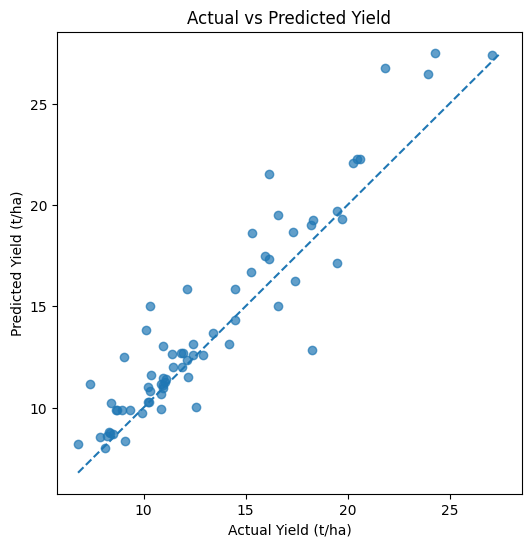

In [10]:
plt.figure(figsize=(6, 6))

plt.scatter(
    final_results[
        "Actual_Yield_t_ha"
    ],
    final_results[
        "Predicted_Yield_t_ha"
    ],
    alpha=0.7
)

lo = min(
    final_results[
        "Actual_Yield_t_ha"
    ].min(),
    final_results[
        "Predicted_Yield_t_ha"
    ].min()
)

hi = max(
    final_results[
        "Actual_Yield_t_ha"
    ].max(),
    final_results[
        "Predicted_Yield_t_ha"
    ].max()
)

plt.plot(
    [lo, hi],
    [lo, hi],
    "--"
)

plt.xlabel(
    "Actual Yield (t/ha)"
)
plt.ylabel(
    "Predicted Yield (t/ha)"
)
plt.title(
    "Actual vs Predicted Yield"
)
plt.show()

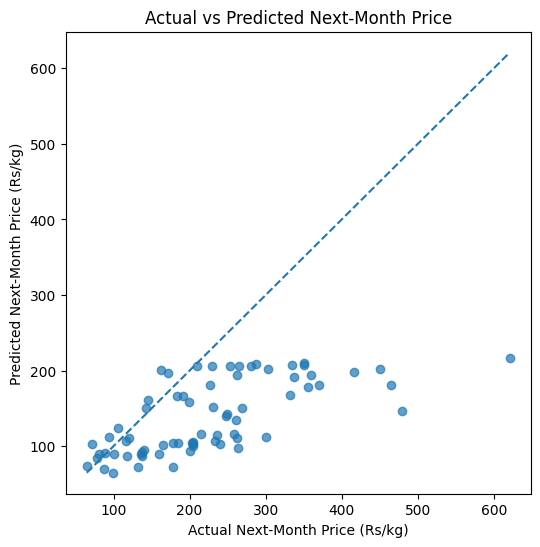

In [11]:
plt.figure(figsize=(6, 6))

plt.scatter(
    final_results[
        "Actual_NextMonthPrice_RsKg"
    ],
    final_results[
        "Predicted_NextMonthPrice_RsKg"
    ],
    alpha=0.7
)

lo = min(
    final_results[
        "Actual_NextMonthPrice_RsKg"
    ].min(),
    final_results[
        "Predicted_NextMonthPrice_RsKg"
    ].min()
)

hi = max(
    final_results[
        "Actual_NextMonthPrice_RsKg"
    ].max(),
    final_results[
        "Predicted_NextMonthPrice_RsKg"
    ].max()
)

plt.plot(
    [lo, hi],
    [lo, hi],
    "--"
)

plt.xlabel(
    "Actual Next-Month Price (Rs/kg)"
)
plt.ylabel(
    "Predicted Next-Month Price (Rs/kg)"
)
plt.title(
    "Actual vs Predicted Next-Month Price"
)
plt.show()

In [12]:
SEASON_ANCHOR_MONTH = {
    "Yala": 4,
    "Maha": 9
}

DATA_SOURCES = {
    "production":
        "researchData.xlsx",

    "weather":
        "weatherData.csv + locationData.csv",

    "weekly_price":
        "Weekly Average Retail Prices of Vegi - 2012 to 2025.xlsx"
}

joblib.dump(
    final_model,
    REPO_PATH
    / "final_multioutput_model.joblib"
)

metadata = {
    "selected_model":
        BEST_MODEL_NAME,

    "features":
        FEATURES,

    "targets":
        TARGETS,

    "common_modelling_period":
        [2012, 2023],

    "train_years":
        [2012, 2019],

    "validation_years":
        [2020, 2021],

    "test_years":
        [2022, 2023],

    "season_anchor_month":
        SEASON_ANCHOR_MONTH,

    "weather_rule":
        "Only the three complete months before each forecast date are used.",

    "leakage_rule":
        "WeatherWindowEnd must be earlier than ForecastDate.",

    "random_state":
        RANDOM_STATE,

    "test_metrics":
        test_metrics,

    "data_sources":
        DATA_SOURCES
}

with open(
    REPO_PATH
    / "model_metadata.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        metadata,
        f,
        indent=2
    )

print("Final model saved.")

Final model saved.


In [13]:
yield_reference = (
    model_data[
        model_data["Year"] <= 2021
    ]
    .groupby("Crop")[
        "Yield_t_ha"
    ]
    .median()
    .to_dict()
)


def predict_plan(
    crop,
    season,
    year,
    planned_extent_ha,
    rainfall_3m_mm,
    temp_mean_3m_c,
    wind_speed_3m_kmh,
    solar_radiation_3m_mj_m2,
    et0_3m_mm,
    prev_month_price_rs_kg
):
    row = pd.DataFrame([{
        "Crop":
            crop,

        "Season":
            season,

        "Year":
            year,

        "Rainfall_3M_mm":
            rainfall_3m_mm,

        "TempMean_3M_C":
            temp_mean_3m_c,

        "WindSpeed_3M_kmh":
            wind_speed_3m_kmh,

        "SolarRadiation_3M_MJ_m2":
            solar_radiation_3m_mj_m2,

        "ET0_3M_mm":
            et0_3m_mm,

        "PrevMonthWholesalePrice_RsKg":
            prev_month_price_rs_kg
    }])

    pred = final_model.predict(
        row
    )[0]

    pred_yield = max(
        0.0,
        float(pred[0])
    )

    pred_price = max(
        0.0,
        float(pred[1])
    )

    expected_production = (
        pred_yield
        * planned_extent_ha
    )

    price_change_pct = (
        (
            pred_price
            - prev_month_price_rs_kg
        )
        /
        prev_month_price_rs_kg
        * 100
        if prev_month_price_rs_kg > 0
        else np.nan
    )

    crop_median = (
        yield_reference.get(
            crop,
            np.nan
        )
    )

    yield_good = (
        np.isnan(crop_median)
        or pred_yield >= crop_median
    )

    if (
        price_change_pct >= 5
        and yield_good
    ):
        recommendation = (
            "Favourable signal: expected yield is reasonable/high "
            "and next-month price is predicted to rise."
        )

    elif (
        price_change_pct <= -5
        and yield_good
    ):
        recommendation = (
            "Caution: expected yield is reasonable/high but "
            "next-month price may fall."
        )

    elif (
        price_change_pct >= 5
        and not yield_good
    ):
        recommendation = (
            "Mixed signal: price may improve, but predicted "
            "yield is below the historical median."
        )

    else:
        recommendation = (
            "Neutral/cautious signal: check costs, local conditions "
            "and current market information."
        )

    return {
        "Predicted Yield (t/ha)":
            round(
                pred_yield,
                2
            ),

        "Expected Production (tonnes)":
            round(
                expected_production,
                2
            ),

        "Predicted Next-Month Wholesale Price (Rs/kg)":
            round(
                pred_price,
                2
            ),

        "Predicted Price Change (%)":
            None
            if np.isnan(
                price_change_pct
            )
            else round(
                price_change_pct,
                2
            ),

        "Recommendation":
            recommendation,

        "Decision Support Note":
            (
                "Price prediction showed weak out-of-sample performance, so this recommendation "
                "is experimental decision support and should not be used alone."
                if test_metrics["NextMonthWholesalePrice_RsKg"]["R2"] < 0
                else
                "This is a planning signal, not a guaranteed future outcome."
            )
    }

In [15]:
example_index = (
    X_test.index[0]
)

example = X_test.loc[
    example_index
]

result = predict_plan(
    crop=example["Crop"],
    season=example["Season"],
    year=int(example["Year"]),
    planned_extent_ha=1.0,
    rainfall_3m_mm=float(example["Rainfall_3M_mm"]),
    temp_mean_3m_c=float(example["TempMean_3M_C"]),
    wind_speed_3m_kmh=float(example["WindSpeed_3M_kmh"]),
    solar_radiation_3m_mj_m2=float(
        example["SolarRadiation_3M_MJ_m2"]
    ),
    et0_3m_mm=float(example["ET0_3M_mm"]),
    prev_month_price_rs_kg=float(
        example["PrevMonthWholesalePrice_RsKg"]
    )
)

print("FINAL MODEL OUTPUT")
print(
    json.dumps(
        result,
        indent=2
    )
)

with open(
    REPO_PATH
    / "final_recommendation_example.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        result,
        f,
        indent=2
    )

FINAL MODEL OUTPUT
{
  "Predicted Yield (t/ha)": 11.16,
  "Expected Production (tonnes)": 11.16,
  "Predicted Next-Month Wholesale Price (Rs/kg)": 107.13,
  "Predicted Price Change (%)": -22.55,
  "Recommendation": "Caution: expected yield is reasonable/high but next-month price may fall.",
  "Decision Support Note": "Price prediction showed weak out-of-sample performance, so this recommendation is experimental decision support and should not be used alone."
}


In [16]:
limitations = pd.DataFrame([
    [
        "Weather",
        "The model uses national aggregated weather and cannot represent every farm's microclimate."
    ],
    [
        "Production",
        "Yield can also depend on soil, fertilizer, irrigation, pests, disease, seed variety and farm practice."
    ],
    [
        "Market price",
        (
            "Prices can change because of demand, transport costs, imports, inflation, festivals and unexpected events. "
            f"Final test price R2 = {test_metrics['NextMonthWholesalePrice_RsKg']['R2']:.4f}; "
            "this weakness must be stated in the report."
        )
    ],
    [
        "Time coverage",
        "The final model uses the common reliable period 2012-2023."
    ],
    [
        "Decision support",
        "Predictions support planning and should not replace farmer experience or agricultural advice."
    ]
], columns=[
    "Area",
    "Limitation_or_Note"
])

limitations.to_csv(
    REPO_PATH
    / "recommendation_limitations.csv",
    index=False
)

display(limitations)

print("\nFinal output files:")
for name in [
    "Preprocessed Datasets/04_final_modelling_dataset.csv",
    "validation_model_comparison.csv",
    "final_test_metrics.csv",
    "final_test_predictions.csv",
    "final_multioutput_model.joblib",
    "model_metadata.json",
    "final_recommendation_example.json",
    "recommendation_limitations.csv"
]:
    print(name)

,Area,Limitation_or_Note
0,Weather,The model uses national aggregated weather and...
1,Production,"Yield can also depend on soil, fertilizer, irr..."
2,Market price,"Prices can change because of demand, transport..."
3,Time coverage,The final model uses the common reliable perio...
4,Decision support,Predictions support planning and should not re...



Final output files:
Preprocessed Datasets/04_final_modelling_dataset.csv
validation_model_comparison.csv
final_test_metrics.csv
final_test_predictions.csv
final_multioutput_model.joblib
model_metadata.json
final_recommendation_example.json
recommendation_limitations.csv


In [ ]:
from getpass import getpass
from google.colab import _message
import subprocess

MEMBER_NAME = "Gunathilake B.M.P"
NOTEBOOK_NAME = "04_IT23361690_Gunathilake_BMP_Final_Model.ipynb"

FILES_TO_ADD = [
    "Preprocessed Datasets/04_final_modelling_dataset.csv",
    "validation_model_comparison.csv",
    "final_test_metrics.csv",
    "final_test_predictions.csv",
    "final_multioutput_model.joblib",
    "model_metadata.json",
    "final_recommendation_example.json",
    "recommendation_limitations.csv"
]

current_notebook = _message.blocking_request(
    "get_ipynb",
    request="",
    timeout_sec=10
)

notebook_path = REPO_PATH / NOTEBOOK_NAME

with open(
    notebook_path,
    "w",
    encoding="utf-8"
) as f:
    json.dump(
        current_notebook["ipynb"],
        f,
        ensure_ascii=False,
        indent=1
    )

print("Saved notebook:", notebook_path.name)

github_email = input("GitHub email: ").strip()
github_username = input("GitHub username: ").strip()
github_token = getpass("GitHub Personal Access Token: ")

subprocess.run(
    ["git", "config", "user.name", MEMBER_NAME],
    cwd=REPO_PATH,
    check=True
)

subprocess.run(
    ["git", "config", "user.email", github_email],
    cwd=REPO_PATH,
    check=True
)

for item in [NOTEBOOK_NAME] + FILES_TO_ADD:
    subprocess.run(
        ["git", "add", item],
        cwd=REPO_PATH,
        check=True
    )

status = subprocess.run(
    ["git", "status", "--short"],
    cwd=REPO_PATH,
    text=True,
    capture_output=True,
    check=True
)

print(status.stdout)

if status.stdout.strip():
    subprocess.run(
        [
            "git",
            "commit",
            "-m",
            "Member 4: Update leakage-safe final model evaluation and recommendation"
        ],
        cwd=REPO_PATH,
        check=True
    )
else:
    print("Nothing new to commit.")

askpass = Path("/tmp/git_askpass.sh")

askpass.write_text(
    '#!/bin/sh\n'
    'case "$1" in\n'
    '  *Username*) echo "$GITHUB_USERNAME" ;;\n'
    '  *Password*) echo "$GITHUB_TOKEN" ;;\n'
    'esac\n'
)

askpass.chmod(0o700)

env = os.environ.copy()
env["GITHUB_USERNAME"] = github_username
env["GITHUB_TOKEN"] = github_token
env["GIT_ASKPASS"] = str(askpass)

result = subprocess.run(
    ["git", "push", "origin", "main"],
    cwd=REPO_PATH,
    env=env,
    text=True,
    capture_output=True
)

print(result.stdout)
print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(
        "Push failed. Check the GitHub username, token and repository permission."
    )

print("Push completed.")